In [97]:
import pickle
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
with open('../data_and_models/cleaned_data.pkl', 'rb') as f:
    cleaned_data = pickle.load(f)

In [126]:
# 1. Load the Pickle files to preserve objects
tree_df = pd.read_pickle("../data_and_models/search_results_tree_k1_n5.pkl") 
rl_df = pd.read_pickle("rl_greedy_eval.pkl")
prob_df = pd.read_pickle("../data_and_models/probabilistic_search_results_paths50_steps5.pkl")
beam20_df = pd.read_pickle("../data_and_models/search_results_beam_k20_n5.pkl")

def get_absolute_best_sets(df):
    """
    Finds the absolute closest point reached during the search for each cell,
    regardless of which step (1-5) it occurred on.
    """
    # Filter for the 'best at step' candidates
    bests = df[df['is_best_at_step'] == True]
    
    # For each cell line, find the index of the row with the absolute minimum final_distance
    # This handles the case where the 2nd or 3rd step was better than the 5th
    idx = bests.groupby('starting_cl')['final_distance'].idxmin()
    
    # Extract those rows and convert the drug_sequence to a set
    absolute_best_df = bests.loc[idx]
    return absolute_best_df.set_index('starting_cl')['drug_sequence'].apply(set)

# 2. Extract the best pharmacological sets from both
tree_best_sets = get_absolute_best_sets(tree_df)
rl_best_sets = get_absolute_best_sets(rl_df)

# 3. Compare common cell lines
common_cells = tree_best_sets.index.intersection(rl_best_sets.index)
jaccard_scores = []

for cell in common_cells:
    s_tree = tree_best_sets[cell]
    s_rl = rl_best_sets[cell]
    
    # Jaccard Index: (Intersection / Union)
    intersection = len(s_tree & s_rl)
    union = len(s_tree | s_rl)
    
    jaccard = intersection / union if union > 0 else 0
    jaccard_scores.append(jaccard)

# 4. Final Output
print(f"--- Absolute Best Sanity Check (Step-Agnostic) ---")
print(f"Cells Analyzed: {len(common_cells)}")
print(f"Avg Jaccard Similarity: {np.mean(jaccard_scores):.1%}")
print(f"Full Biological Alignment (Jaccard=1.0): {jaccard_scores.count(1.0)} cells")

--- Absolute Best Sanity Check (Step-Agnostic) ---
Cells Analyzed: 5
Avg Jaccard Similarity: 24.4%
Full Biological Alignment (Jaccard=1.0): 1 cells


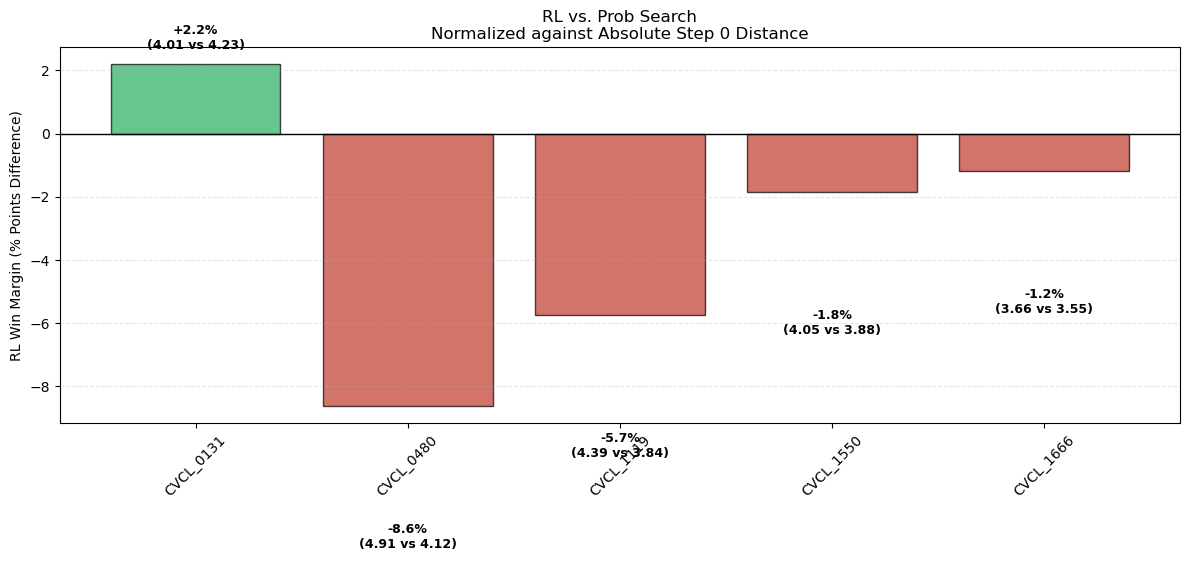

In [129]:
def compare_and_plot_performance(rl_df, tree_df):
    """
    Calculates the honest win margin relative to the Step 0 baseline 
    and generates a bar chart comparing RL vs. Tree search.
    """
    # 1. Identify common cell lines
    common_cells = sorted(list(set(rl_df['starting_cl']) & set(tree_df['starting_cl'])))
    
    results = []
    for cl in common_cells:
        # 2. Get the global baseline distance (Step 0)
        # We use .max() to ensure we get the initial 6.161856 distance
        baseline = tree_df[tree_df['starting_cl'] == cl]['starting_distance'].max()
        
        # 3. Get the absolute lowest final distance achieved anywhere in the datasets
        rl_best_final = rl_df[rl_df['starting_cl'] == cl]['final_distance'].min()
        tree_best_final = tree_df[tree_df['starting_cl'] == cl]['final_distance'].min()
        
        # 4. Calculate Normalized Improvement %
        rl_imp = (baseline - rl_best_final) / baseline
        tree_imp = (baseline - tree_best_final) / baseline
        
        # 5. Margin: How much more (or less) progress did RL make than the Tree?
        win_margin = (rl_imp - tree_imp) * 100
        
        results.append({
            'Cell Line': cl,
            'Margin': win_margin,
            'RL_Best': rl_best_final,
            'Tree_Best': tree_best_final
        })

    df_comp = pd.DataFrame(results)

    # 6. Plotting
    plt.figure(figsize=(12, 6))
    colors = ['#27ae60' if x >= 0 else '#c0392b' for x in df_comp['Margin']]
    bars = plt.bar(df_comp['Cell Line'], df_comp['Margin'], color=colors, edgecolor='black', alpha=0.7)
    
    plt.axhline(0, color='black', linewidth=1)
    plt.ylabel('RL Win Margin (% Points Difference)')
    plt.title('RL vs. Prob Search\nNormalized against Absolute Step 0 Distance')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    # Add numeric labels showing the margin and the absolute final distances
    for bar, row in zip(bars, results):
        yval = bar.get_height()
        # Label shows the margin and (RL dist vs Tree dist)
        label = f"{yval:+.1f}%\n({row['RL_Best']:.2f} vs {row['Tree_Best']:.2f})"
        plt.text(bar.get_x() + bar.get_width()/2, yval + (0.5 if yval > 0 else -4.5), 
                 label, ha='center', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()
    
    return df_comp


comparison_df = compare_and_plot_performance(rl_df, tree_df)

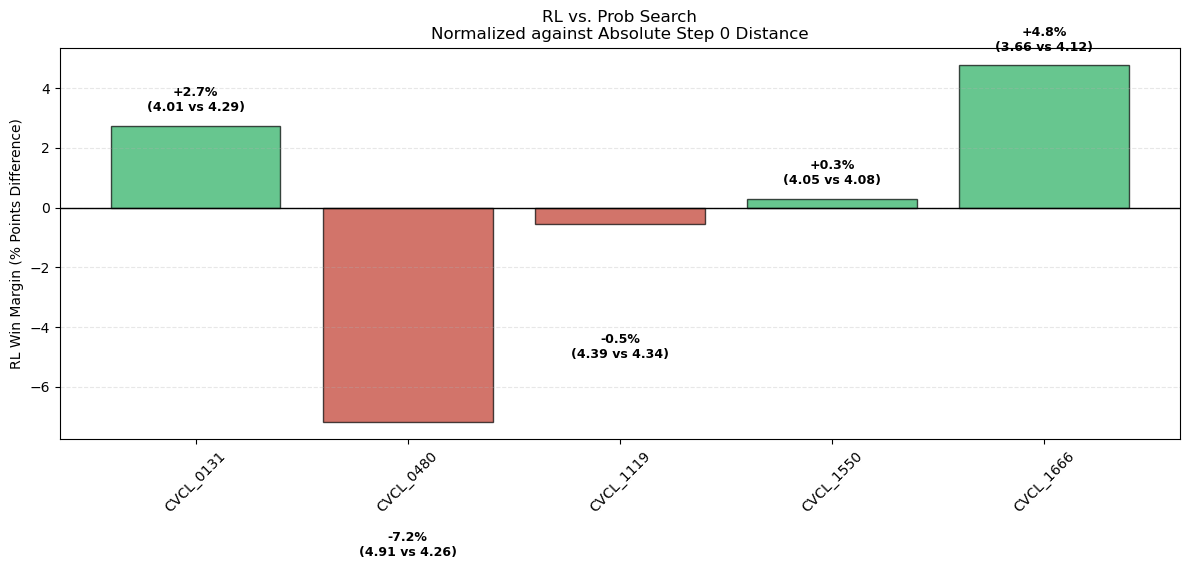

In [130]:
comparison_df = compare_and_plot_performance(rl_df, prob_df)

In [117]:
test_cells = rl_df['starting_cl'].unique().tolist()

In [118]:
val_cells = ['CVCL_0359', 'CVCL_1094', 'CVCL_1097', 'CVCL_1098', 'CVCL_1717']

In [122]:
def analyze_performance_gap(df, val_cells, test_cells):
    """
    Calculates the gap in progress between Validation cells and Training cells.
    Excludes Test cells from the baseline to ensure a clean comparison.
    """
    # 1. Calculate progress: (Start - Final) / Start
    df['progress'] = (df['starting_distance'] - df['final_distance']) / (df['starting_distance'] + 1e-6)
    
    # 2. Get the maximum progress achieved for every unique cell line
    best_per_cell = df.groupby('starting_cl')['progress'].max()
    
    # 3. Categorize cell lines
    val_mask = best_per_cell.index.isin(val_cells)
    test_mask = best_per_cell.index.isin(test_cells)
    # Train cells are everything else (neither Val nor Test)
    train_mask = ~(val_mask | test_mask)
    
    avg_val = best_per_cell[val_mask].mean()
    avg_train = best_per_cell[train_mask].mean()
    avg_test = best_per_cell[test_mask].mean() if any(test_mask) else 0
    
    # 4. Calculate Overfitting Gap: (Train - Val)
    # A positive gap means the model performs better on training data than validation.
    gap = avg_train - avg_val
    
    print(f"--- 80-10-10 Performance Analysis ---")
    print(f"Train Cells Avg Progress: {avg_train:.2%}")
    print(f"Val Cells Avg Progress:   {avg_val:.2%}")
    print(f"Test Cells Avg Progress:  {avg_test:.2%}")
    print("-" * 38)
    print(f"Overfitting Gap (Train - Val): {gap:+.2%}")
    
    return gap

In [123]:
analyze_performance_gap(tree_df, val_cells, test_cells)

--- 80-10-10 Performance Analysis ---
Train Cells Avg Progress: 46.89%
Val Cells Avg Progress:   47.08%
Test Cells Avg Progress:  40.56%
--------------------------------------
Overfitting Gap (Train - Val): -0.19%


np.float64(-0.0018996407076983246)

In [127]:
analyze_performance_gap(beam20_df, val_cells, test_cells)

--- 80-10-10 Performance Analysis ---
Train Cells Avg Progress: 51.47%
Val Cells Avg Progress:   54.89%
Test Cells Avg Progress:  46.99%
--------------------------------------
Overfitting Gap (Train - Val): -3.42%


np.float64(-0.034206514294010115)

--- Distribution of Path Lengths (Number of Drugs) ---
      Beam190  RL_Agent
step                   
2.0         0         1
3.0         1         2
4.0         6         2
5.0        41         5


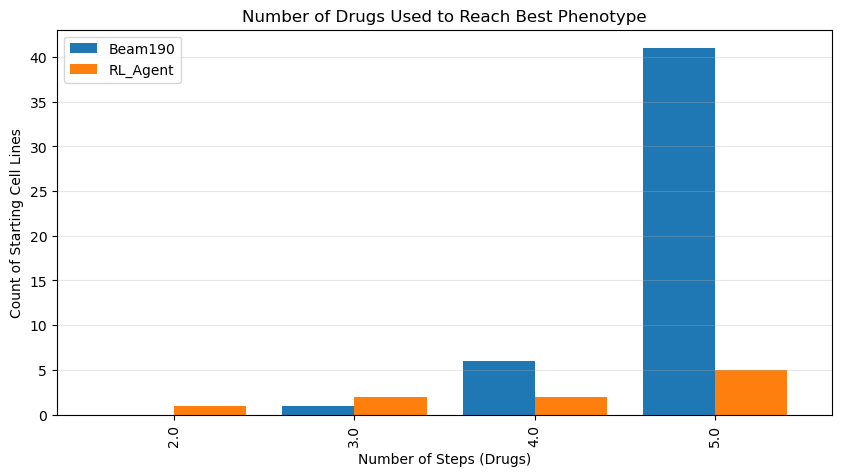

In [24]:
def print_path_length_distribution(beam_df, rl_df):
    """
    Analyzes how many steps (drugs) it took to reach the best phenotype.
    """
    # 1. Identify the absolute best row for each starting cell
    # We find the index of the minimum distance for each cell line
    beam_best_idx = beam_df[beam_df['is_best_at_step'] == True].groupby('starting_cl')['final_distance'].idxmin()
    rl_best_idx = rl_df[rl_df['is_best_at_step'] == True].groupby('starting_cl')['final_distance'].idxmin()
    
    # 2. Extract the 'step' column for these rows
    # This represents the number of drugs used to reach that best point
    beam_steps = beam_df.loc[beam_best_idx, 'step']
    rl_steps = rl_df.loc[rl_best_idx, 'step']

    # 3. Calculate frequencies
    beam_dist = beam_steps.value_counts().sort_index()
    rl_dist = rl_steps.value_counts().sort_index()

    print("--- Distribution of Path Lengths (Number of Drugs) ---")
    summary = pd.DataFrame({'Beam190': beam_dist, 'RL_Agent': rl_dist}).fillna(0).astype(int)
    print(summary)

    # 4. Visualization
    summary.plot(kind='bar', figsize=(10, 5), width=0.8)
    plt.title("Number of Drugs Used to Reach Best Phenotype")
    plt.xlabel("Number of Steps (Drugs)")
    plt.ylabel("Count of Starting Cell Lines")
    plt.grid(axis='y', alpha=0.3)
    plt.show()

# Run the distribution check
print_path_length_distribution(beam_df, rl_df)

In [25]:
import pandas as pd
import numpy as np

# Load the RL result file
rl_df = pd.read_pickle("rl_greedy_eval.pkl")

# 1. Find the Absolute Best Step (minimum distance achieved)
# We look only at rows where is_best_at_step is True to follow valid search branches
best_candidates = rl_df[rl_df['is_best_at_step'] == True]
idx_best = best_candidates.groupby('starting_cl')['final_distance'].idxmin()
rl_best_rows = rl_df.loc[idx_best]

# 2. Analyze the 'Peak Step' Distribution
# This tells us if the agent finds the target early and then wanders away.
peak_step_dist = rl_best_rows['step'].value_counts().sort_index()
print("--- Distribution of the 'Best' Step ---")
print(peak_step_dist)

# 3. Analyze the 'Progress Stall'
# Calculate progress at step 1 vs final step
step1 = rl_df[rl_df['step'] == 1].set_index('starting_cl')['final_distance']
step5 = rl_df[rl_df['step'] == 5].set_index('starting_cl')['final_distance']
progression = step1 - step5
print(f"\nAvg Distance change from Step 1 to 5: {progression.mean():.4f}")

--- Distribution of the 'Best' Step ---
step
2    1
3    2
4    2
5    5
Name: count, dtype: int64

Avg Distance change from Step 1 to 5: 1.1575
